# Lagged Correlations

## Package imports

In [1]:
# filter some warning messages
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import scipy
from scipy import stats
import numpy as np
import pandas as pd
import xarray as xr
from os import path
# import xesmf as xe
import scipy.signal as signal
from scipy.signal import detrend
import turtle
import dask.array as da
import intake
import cartopy.crs as ccrs
import gsw
import pickle as pkl
from datetime import datetime


os.environ['NUMPY_EXPERIMENTAL_ARRAY_FUNCTION'] = '0'
warnings.filterwarnings("ignore")
# import PyCO2SYS as pyco2


import dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client


## plotting stuff
import cartopy.crs as ccrs # for map projections
import cartopy.feature as cfeature # for map features like coastline, etc.
from cartopy.util import add_cyclic_point # get rid of the white line at 0 degree longitude for some models
import matplotlib.path as mpath
import cmocean # a nice collection of colormap

## Model used

In [2]:
model = "GFDL-CM4"

## Pulling CMIP DATA Function

In [3]:
def get_path(model, variable, data_type, experiment_id, activity_id):
   
    import intake
    
    member_id_list = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f2", "r1i1p2f1", "r4i1p1f1","r13i1p1f2", "r101i1p1f1"]
    grid_list = ["gr", "gn"] 
    
    url_cimp6 = '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    cat = intake.open_esm_datastore(url_cimp6)
    cat.df.head()
    
    selected_run = None
    selected_grid = None
    
    for run in member_id_list:
        cat_subset = cat.search(
            experiment_id=[experiment_id],
            table_id= data_type,
            variable_id= variable,
            source_id=model,
            member_id=run,
            activity_id = activity_id
        )
        
        if not cat_subset.df.empty:  # If we find a valid run, store it
            selected_run = run
            
            # Now try different grid labels
            for grid in grid_list:
                #print(f"Trying grid: {grid}")  
                cat_subset = cat.search(
                    experiment_id=[experiment_id],
                    table_id= data_type,
                    variable_id= variable,
                    source_id= model,
                    member_id=selected_run,
                    activity_id = activity_id,
                    grid_label=grid
                )
    
                if not cat_subset.df.empty:  # If we find a valid grid, store it and stop
                    selected_grid = grid
                    break  # Stop searching for grids
    
            break  # Stop searching for runs once we find a valid one
    
    #print(f"Selected run: {selected_run}, Selected grid: {selected_grid}")
    path = cat_subset.df["path"].tolist()
    return path


In [4]:
path_test = get_path(model,"volcello", "Omon", "historical","CMIP")
test_data = xr.open_mfdataset(path_test, chunks = None)


In [5]:
test_data

<xarray.Dataset> Size: 18GB
Dimensions:    (time: 1980, lat: 180, bnds: 2, lon: 360, lev: 35)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lev        (lev) float64 280B 2.5 10.0 20.0 32.5 ... 5.5e+03 6e+03 6.5e+03
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 6MB dask.array<chunksize=(240, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 11MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    volcello   (time, lev, lat, lon) float32 18GB dask.array<chunksize=(1, 18, 90, 180), meta=np.ndarray>
    lev_bnds   (time, lev, bnds) float64 1MB dask.array<chunksize=(240, 35, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello volcello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    variable_id:            volcello
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    branch_time_in_parent:  36500.0
    parent_time_units:      days since 0001-1-1

## Create Convection Masks

Deep Convection will be defined as areas where the mixed layer depth (MLD) reached a depth greater than 2000 meters in the month of september (SO winter). Right now I will use the models saved version of MLD. 

In [6]:
#get the path to the MLD data for the choosen model 
#function form take arguments: model, variable, data_type, experiment_id, activity_id - see above
    #here I am using the model GFDL-CM4, pulling MLD data, in the Ocean Monthly (Omon) format, for the //
    #pre-industrial control experiment in the CMIP file 

path_mld = get_path(model,"mlotst", "Omon", "piControl","CMIP")
#print(path_mld)

In [7]:
MODEL_MLD = xr.open_mfdataset(path_mld, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
MODEL_MLD_SO = MODEL_MLD.sel(lat=slice(-90, -40)) #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_MLD_SO_sept = MODEL_MLD_SO.sel(time=MODEL_MLD_SO['time'].dt.month == 9) # pull the september month data (results in 500 point time dimension - 1 month for 500 yrs) 

#display dataset to see vars and dimesions 
MODEL_MLD_SO_sept 

<xarray.Dataset> Size: 39MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d9acf7e3-3970-44c5-bb0d-57ec2bc0c5ad
    variable_id:            mlotst
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

**Deep Convection Area Mask**

For every year in the 500 year time period, check if the MLD is greater than or equal to 2000 m. If it is then write a value of 1, if it is not, write a value of zero. Results in a mask with dimensions of lat, lon, time 

In [8]:
#1 where the mixed-layer depth (MLD) is ≥ 2000 (“deep convection” criterion), and 0 everywhere else
convection_area_mask = xr.where(MODEL_MLD_SO_sept>=2000, 1, 0)  # this is the mask of deep convection (x, y, t)

#display mask to check dimensions and vars
convection_area_mask

<xarray.Dataset> Size: 75MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) int64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) int64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) int64 72MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) int64 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>

**ross deep convection mask**

In [9]:
## ross sea convection mask (bottom blob) 
convection_area_mask_ross = convection_area_mask.where(
    (convection_area_mask.lon >= 150) & (convection_area_mask.lon <= 240),
    other=0)

In [10]:
convection_area_mask_ross_plot = convection_area_mask_ross['mlotst'].mean("time")

Text(0.5, 1.0, 'mask ross')

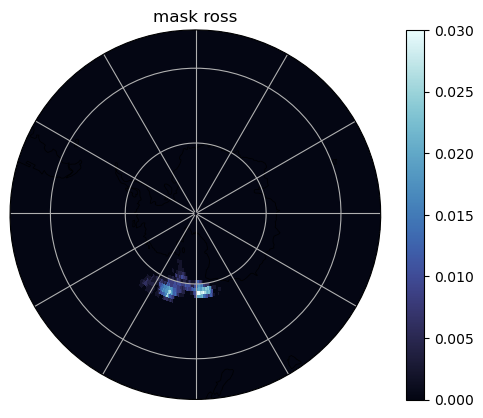

In [11]:
#mapping code 
ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# add some map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# add gridline
gl = ax.gridlines(
    xlocs = np.arange(-180,180,30),
    ylocs = np.arange(-90,90,20))

## Unit conversion 
#VAR_deepconvection_plot_c = (VAR_deepconvection_plot * 1000) / 101.325

# use pcolormesh to plot the 2D data array
im = ax.pcolormesh(convection_area_mask_ross_plot.lon, convection_area_mask_ross_plot.lat, convection_area_mask_ross_plot, 
                   transform=ccrs.PlateCarree(), # indicate the coordinate system 
                   cmap=cmocean.cm.ice) # use colormap from cmocean

cbar = plt.colorbar(im) # plot colorbar

plt.title('mask ross') 

**wedell deep convection mask** 

In [12]:
## weddell sea convection mask (bottom blob) 

convection_area_mask_weddell = convection_area_mask.where(
    (convection_area_mask.lon >= 300) | (convection_area_mask.lon <= 30),
    other=0)



**Total Convection Area Mask**

This mask gives the total area than has deep convection in any of the 500 years, sort of the total area that has potential for deep convection. Gives a 1 for the area that is deep convection  

In [13]:
convection_total_mask = xr.where(convection_area_mask.mean("time") > 0, 1, 0)   # this is the mask of total convection area (x, y)
# gives a one wherever deep convection has occured in any of the 500 years

#display mask to check dimensions and vars
convection_total_mask

<xarray.Dataset> Size: 154kB
Dimensions:    (lat: 50, bnds: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) int64 800B dask.array<chunksize=(50, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) int64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    mlotst     (lat, lon) int64 144kB dask.array<chunksize=(50, 360), meta=np.ndarray>
    time_bnds  (bnds) int64 16B dask.array<chunksize=(2,), meta=np.ndarray>

**ross total convection mask**

In [14]:
## ross sea convection mask (bottom blob) 
tot_convection_area_mask_ross = convection_total_mask.where(
    (convection_area_mask.lon >= 150) & (convection_area_mask.lon <= 240),
    other=0)

## Pulling datasets

In [15]:
def CMIPModel_SO_Timeseries(variable, data_xarray, convection_mask): 
    ###############################################################
    ##Function to take cmip data pulled and turn into timeseries
    ##############################################################
    #data_xarray is the data output from CMIP model opened into an xarray
    variable = variable
    MODEL_VAR = data_xarray
    MODEL_VAR_SO = MODEL_VAR.sel(lat=slice(-90, -40))  #pull only southern ocean latitudes (avoid unneccecary computation) 
    MODEL_VAR_SO_sept = MODEL_VAR_SO.sel(time=MODEL_VAR_SO['time'].dt.month == 9) # pull the September month data (results in 500 point time dimension - 1 month for 500 yrs) 

    if 'lev' in MODEL_VAR_SO_sept.coords:
        MODEL_VAR_SO_sept_surface =  MODEL_VAR_SO_sept.isel(lev=0) #Pull only surface levels of nutrient for now 
    else: 
        MODEL_VAR_SO_sept_surface =  MODEL_VAR_SO_sept

    ##Convection masked areas 
    # ensure mask is boolean, same dims
    convection_mask = convection_mask
    mask_deepConvection = (convection_mask == 1)
    
    # align mask before applying -> make sure all dimensions are the same
    #fills any missing dimensions with nans, aligns dimensions 
    #used sept, surface po4 data for SO 
    mask_deepConvection_aligned, VAR_aligned = xr.align(mask_deepConvection, MODEL_VAR_SO_sept_surface)
    
    VAR_deepconvection = VAR_aligned.where(mask_deepConvection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 
    
    # ensure correct variables and dimensions preserved 
    #VAR_deepconvection
    VAR_deepconvection_ts = VAR_deepconvection[variable].mean('lat').mean('lon')

    return VAR_deepconvection_ts

In [16]:
model = "GFDL-CM4"
########convection index###########
with open("/glade/u/home/shunzlu/share_data/heat_content_rs_sep.pickle", "rb") as f:
    heat_content = pkl.load(f)

conv_index = -1 * heat_content
#time = np.linspace(0,500,500)
#plt.plot(time, heat_content)

######sea ice concentration########
path_SIC = get_path(model,"siconc", "SImon", "piControl","CMIP")
MODEL_SIC = xr.open_mfdataset(path_SIC, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
SIC_ross_ts = CMIPModel_SO_Timeseries("siconc",MODEL_SIC, tot_convection_area_mask_ross)

######sea ice thickness########
path_SIT = get_path(model,"sisnthick", "SImon", "piControl","CMIP")
MODEL_SIT = xr.open_mfdataset(path_SIT, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
SIT_ross_ts = CMIPModel_SO_Timeseries("sisnthick",MODEL_SIT, tot_convection_area_mask_ross)


##############Air–sea CO₂ flux######### #Net downward flux of CO₂ from the atmosphere into the ocean
path_fgCO2 = get_path(model,"fgco2", "Omon", "piControl","CMIP")
MODEL_fgCO2 = xr.open_mfdataset(path_fgCO2, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
fgCO2_ross_ts = CMIPModel_SO_Timeseries("fgco2",MODEL_fgCO2, tot_convection_area_mask_ross)


##############Sea Surface temperature######### 
path_SST = get_path(model,"tos", "Omon", "piControl","CMIP")
MODEL_SST = xr.open_mfdataset(path_SST, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
SST_ross_ts = CMIPModel_SO_Timeseries("tos",MODEL_SST, tot_convection_area_mask_ross)


##############Sea Surface Salinity######### 
path_SSS = get_path(model,"sos", "Omon", "piControl","CMIP")
MODEL_SSS = xr.open_mfdataset(path_SSS, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
SSS_ross_ts = CMIPModel_SO_Timeseries("sos", MODEL_SSS,tot_convection_area_mask_ross)


############## Surface phosphate ######### 
path_PO4 = get_path(model,"po4", "Omon", "piControl","CMIP")
MODEL_PO4 = xr.open_mfdataset(path_PO4, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
PO4_ross_ts = CMIPModel_SO_Timeseries("po4", MODEL_PO4, tot_convection_area_mask_ross)

############## Surface DIC######### 
path_DIC = get_path(model, "dissic", "Omon", "piControl","CMIP")
MODEL_DIC = xr.open_mfdataset(path_DIC, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
DIC_ross_ts = CMIPModel_SO_Timeseries("dissic", MODEL_DIC, tot_convection_area_mask_ross)

############## Surface pH######### 
path_pH = get_path(model, "ph", "Omon", "piControl","CMIP")
MODEL_pH = xr.open_mfdataset(path_pH, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
pH_ross_ts = CMIPModel_SO_Timeseries("ph", MODEL_pH, tot_convection_area_mask_ross)

############## Surface pco2######### 
path_spco2 = get_path(model, "spco2", "Omon", "piControl","CMIP")
MODEL_spco2 = xr.open_mfdataset(path_spco2, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
spco2_ross_ts = CMIPModel_SO_Timeseries("spco2", MODEL_spco2, tot_convection_area_mask_ross)

############## alkalinity ######### 
path_ALK = get_path(model, "talk", "Omon", "piControl","CMIP")
MODEL_ALK = xr.open_mfdataset(path_ALK, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
ALK_ross_ts = CMIPModel_SO_Timeseries("talk", MODEL_ALK, tot_convection_area_mask_ross)

############## phytoplankton######### 
path_phyc = get_path(model, "phyc", "Omon", "piControl","CMIP")
MODEL_phyc = xr.open_mfdataset(path_phyc, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
phyc_ross_ts = CMIPModel_SO_Timeseries("phyc", MODEL_phyc, tot_convection_area_mask_ross)

############## iron ######### 
path_dfe = get_path(model, "dfe", "Omon", "piControl","CMIP")
MODEL_dfe = xr.open_mfdataset(path_dfe, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
dfe_ross_ts = CMIPModel_SO_Timeseries("dfe", MODEL_dfe, tot_convection_area_mask_ross)




In [17]:
##############Air–sea CO₂ flux######### #Net downward flux of CO₂ from the atmosphere into the ocean
path_fgCO2 = get_path(model,"fgco2", "Omon", "piControl","CMIP")
MODEL_fgCO2 = xr.open_mfdataset(path_fgCO2, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
fgCO2_ross_ts = CMIPModel_SO_Timeseries("fgco2",MODEL_fgCO2, tot_convection_area_mask_ross)



In [18]:
dfe_ross_ts

<xarray.DataArray 'dfe' (time: 500)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(500,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
    lev      float64 8B 2.5
Attributes:
    long_name:      Dissolved Iron Concentration
    units:          mol m-3
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    standard_name:  mole_concentration_of_dissolved_iron_in_sea_water
    interp_method:  conserve_order1
    original_name:  dfe
    comment:        Model data on the 1x1 grid includes values in all cells f...

Text(0.5, 1.0, 'iron')

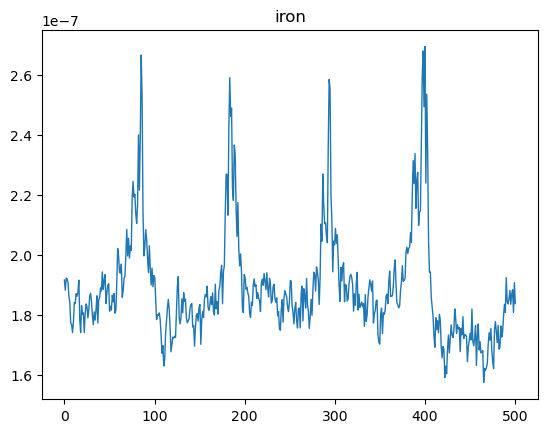

In [19]:
time = np.linspace(0, 500, 500)
plt.plot(time, dfe_ross_ts, label = dfe_ross_ts, linewidth=1)
plt.title("iron")

## Example Case/ Checks

In [20]:
model = "GFDL-CM4"
######sea ice concentration########
path_VAR = get_path(model,"siconc", "SImon", "piControl","CMIP")
#print(path_SIC)
MODEL_VAR = xr.open_mfdataset(path_VAR, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
MODEL_VAR_SO = MODEL_VAR.sel(lat=slice(-90, -40))  #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_VAR_SO_sept = MODEL_VAR_SO.sel(time=MODEL_VAR_SO['time'].dt.month == 9) # pull the September month data (results in 500 point time dimension - 1 month for 500 yrs) 

if 'lev' in MODEL_VAR_SO_sept.coords:
    MODEL_VAR_SO_sept_surface =  MODEL_VAR_SO_sept.isel(lev=0) #Pull only surface levels of nutrient for now 
else: 
    MODEL_VAR_SO_sept_surface =  MODEL_VAR_SO_sept

    
#MODEL_VAR_SO_sept_surface

##Convection masked areas 
# ensure mask is boolean, same dims
mask_deepConvection_ross = (convection_area_mask_ross == 1)

# align mask before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_ross_aligned, VAR_aligned = xr.align(mask_deepConvection_ross, MODEL_VAR_SO_sept_surface)

VAR_deepconvection_ross = VAR_aligned.where(mask_deepConvection_ross_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
VAR_deepconvection_ross

<xarray.Dataset> Size: 468MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    siconc     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               SImon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  54750.0
    ...                     ...
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    tracking_id:            hdl:21.14100/29b16667-5c91-4703-b1c7-4202638c5c4c
    variable_id:            siconc
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [21]:
#flatten time dimension (average over time), pull po4 data//
##to make the dataset into a (flat) dataarray that can be mapped 
### renamed "_plot" version to preserve original dataset for future computations" 
VAR_deepconvection_plot = VAR_deepconvection_ross['siconc'].mean("time")
#ensure dimensions align with expectations (360 x (longitude), 50 y (latitude) 
VAR_deepconvection_plot 

<xarray.DataArray 'siconc' (lat: 50, lon: 360)> Size: 72kB
dask.array<mean_agg-aggregate, shape=(50, 360), dtype=float32, chunksize=(50, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    cell_methods:   area: mean where sea time: mean
    interp_method:  conserve_order1
    long_name:      Sea Ice Area Fraction (Ocean Grid)
    units:          %
    standard_name:  sea_ice_area_fraction
    original_name:  siconc
    cell_measures:  area: areacello
    comment:        Model data on the 1x1 grid includes values in all cells f...

Text(0.5, 1.0, 'SIC in GFDL-CM4 Deep Convection Areas (time averaged)')

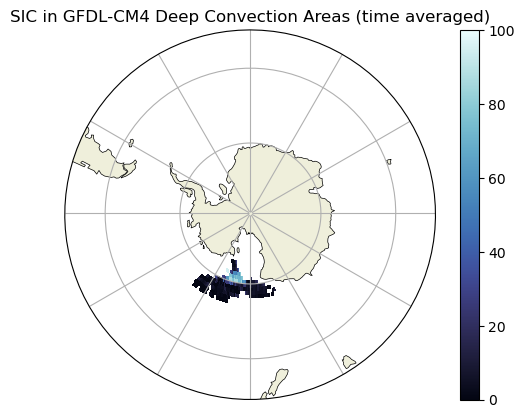

In [22]:
#mapping code 
ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# add some map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# add gridline
gl = ax.gridlines(
    xlocs = np.arange(-180,180,30),
    ylocs = np.arange(-90,90,20))

## Unit conversion 
#VAR_deepconvection_plot_c = (VAR_deepconvection_plot * 1000) / 101.325

# use pcolormesh to plot the 2D data array
im = ax.pcolormesh(VAR_deepconvection_plot.lon, VAR_deepconvection_plot.lat, VAR_deepconvection_plot, 
                   transform=ccrs.PlateCarree(), # indicate the coordinate system 
                   cmap=cmocean.cm.ice,vmin=0, vmax = 100) # use colormap from cmocean

cbar = plt.colorbar(im) # plot colorbar

plt.title('SIC in GFDL-CM4 Deep Convection Areas (time averaged)') 

## Lagged Correlations

In [25]:
def plot_lagged_correlation(x, y, max_lag, p_limit=0.05, color='b', label=None, lw=1.5):
    #from scipy import stats    
    x_norm = (x - np.mean(x)) / np.std(x)
    y_norm = (y - np.mean(y)) / np.std(y)
    x_slice = x_norm[max_lag : len(x_norm) - max_lag]
    window_len = len(x_slice)
    correlations = []
    p_values = []
    
    for i in range(2 * max_lag+1):
        y_slice = y_norm[i : i + window_len]
        reg = stats.linregress(x_slice, y_slice)
        correlations.append(reg.rvalue)
        p_values.append(reg.pvalue)
        
    correlations = np.array(correlations)
    p_values = np.array(p_values)
    lags = np.arange(-max_lag, max_lag+1)
    plt.plot(lags, correlations, color=color, linestyle=':', linewidth=lw, alpha=0.7)
    sig_mask = np.where(p_values < p_limit, correlations, np.nan)
    plt.plot(lags, sig_mask, color=color, linestyle='-', linewidth=lw, label=label)
    

In [26]:
def plot_multi_lagged_correlation(max_lag, lag_center, lag_data_dict, title=None, fig_size=(8, 5),
                                  set_xlim=None, set_ylim=None, colors=None, legend_col=1, lw = 1.5,savename=None):

    fig = plt.figure(figsize = fig_size)
    
    plt.grid(True, which="both", ls="-", color='0.65', alpha=0.5)
    
    if colors is not None:
        colors_list = colors
    else:
        colors_list = plt.cm.tab10.colors

    i = 0
    for data_label, lag_data in lag_data_dict.items():
        plot_lagged_correlation(lag_center, lag_data, max_lag, color=colors_list[i], label=data_label, lw=lw)
        i+=1
    # plt.axhline(0, color='black', linewidth=1, alpha=0.5)    
    plt.xlabel('Year Lag')
    plt.ylabel('Correlation Coefficient (r)')
    
    ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=legend_col)
    
    if title is not None:
        plt.title(title)
    if set_xlim is not None:
        plt.xlim(set_xlim[0], set_xlim[1])
    if set_ylim is not None:
        plt.ylim(set_ylim[0], set_ylim[1])
    if savename is not None:
        fig.savefig(savename, format="pdf")

In [27]:
import matplotlib.pyplot as plt

def plot_multi_lagged_correlation2(
    max_lag,
    lag_center,
    lag_data_dict,
    title=None,
    fig_size=(8, 5),
    set_xlim=None,
    set_ylim=None,
    colors=None,
    legend_col=1,
    lw=1.5,
    savename=None,
):

    fig, ax = plt.subplots(figsize=fig_size)

    ax.grid(True, which="both", ls="-", color="0.65", alpha=0.5)

    if colors is not None:
        colors_list = colors
    else:
        colors_list = plt.cm.tab10.colors

    for i, (data_label, lag_data) in enumerate(lag_data_dict.items()):
        plot_lagged_correlation(
            lag_center,
            lag_data,
            max_lag,
            color=colors_list[i % len(colors_list)],
            label=data_label,
            lw=lw,
        )

    ax.set_xlabel("Year Lag")
    ax.set_ylabel("Correlation Coefficient (r)")

    # --- Legend outside ---
    ax.legend(
        frameon=True,
        ncol=legend_col,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),  # pushes legend outside right
        borderaxespad=0.0,
    )

    if title is not None:
        ax.set_title(title)

    if set_xlim is not None:
        ax.set_xlim(set_xlim)

    if set_ylim is not None:
        ax.set_ylim(set_ylim)

    plt.tight_layout()

    if savename is not None:
        fig.savefig(savename, format="pdf", bbox_inches="tight")

    plt.show()


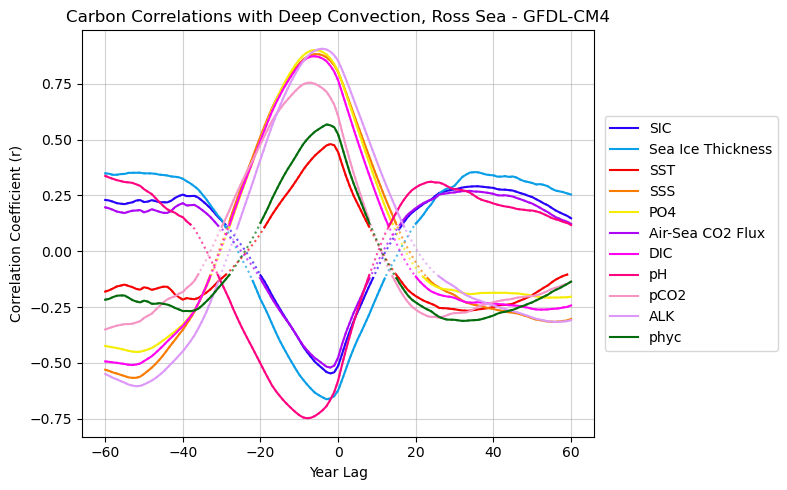

Elapsed time: 3632.15 seconds


In [28]:
import time

start = time.perf_counter()

colors_list = ['#2803fc','#099ee8','#f70000', '#f77c00', '#f5ed05','#ad05f5', 
               '#ff03f2', '#ff0381', '#f595c5', '#dd99f7', '#026b0b']
max_lat = 60
ross_lag_cor__dict = {
    'SIC': SIC_ross_ts,
    'Sea Ice Thickness': SIT_ross_ts,
    'SST': SST_ross_ts,
    'SSS': SSS_ross_ts,
    'PO4': PO4_ross_ts,
    'Air-Sea CO2 Flux': fgCO2_ross_ts,
    'DIC': DIC_ross_ts,
    'pH': pH_ross_ts,
    'pCO2': spco2_ross_ts, 
    'ALK' : ALK_ross_ts,
    'phyc': phyc_ross_ts}




plot_multi_lagged_correlation2(60, conv_index, ross_lag_cor__dict, title= "Carbon Correlations with Deep Convection, Ross Sea - GFDL-CM4", fig_size=(8, 5),
                                  set_xlim=None, set_ylim=None, colors=colors_list, legend_col=1, lw = 1.5,savename=None)

end = time.perf_counter()
print(f"Elapsed time: {end - start:.2f} seconds")

## Timeseries 

'SIC': SIC_ross_ts,'#2803fc'-
    'Sea Ice Thickness': SIT_ross_ts, '#099ee8'
    'SST': SST_ross_ts, '#f70000'-
    'SSS': SSS_ross_ts, '#f77c00'-
    'PO4': PO4_ross_ts, '#f5ed05' - 
    'Air-Sea CO2 Flux': fgCO2_ross_ts, '#ad05f5'-
    'DIC': DIC_ross_ts,'#ff03f2' - 
    'pH': pH_ross_ts,'#ff0381'
    'pCO2': spco2_ross_ts, '#f595c5' - 
    'ALK' : ALK_ross_ts,'#dd99f7' -
    'phyc': phyc_ross_ts'#026b0b'-


sone:
bye
laalal


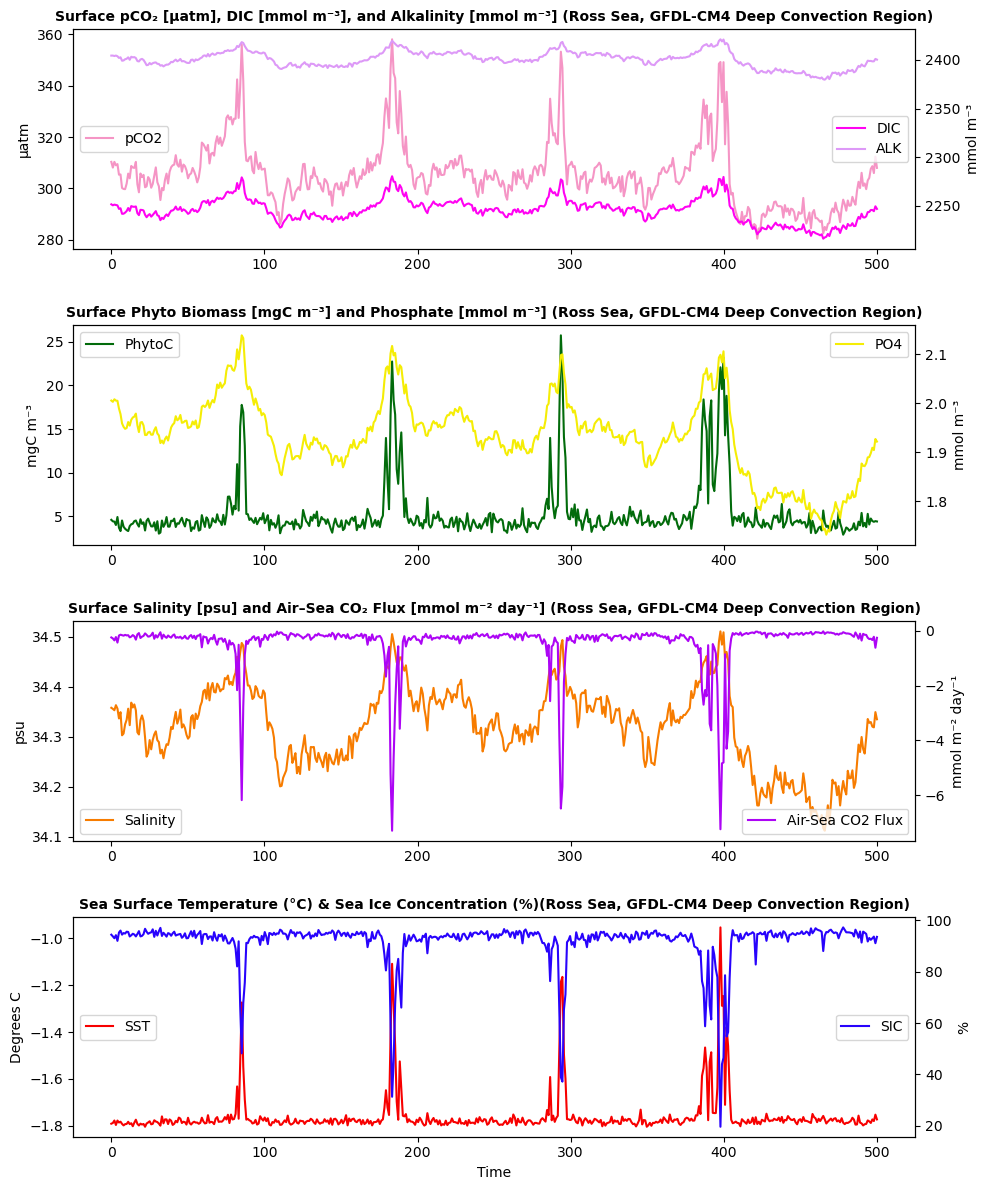

In [30]:
time_x = np.linspace(0, 500, 500)

# Create subplots
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 12),
    sharex=False
)

# -------- Row 1 --------

spco2_ross_ts_plot = (spco2_ross_ts *1000) / 101.325 #Pa -> µatm
ax1 = axes[0]
ax1.plot(time_x, spco2_ross_ts_plot, linestyle="-", color ='#f595c5', label = "pCO2")
ax1.set_ylabel("µatm")
ax1.legend(loc = 'center left')

print('sone:') 
DIC_ross_ts_plot = DIC_ross_ts *(10**3) # mol/m^3 to mmol/m^3
ALK_ross_ts_plot = ALK_ross_ts *(10**3) # mol/m^3 to mmol/m^3
ax1b = ax1.twinx()
ax1b.plot(time_x, DIC_ross_ts_plot, linestyle="-", color ='#ff03f2', label = "DIC")
ax1b.plot(time_x, ALK_ross_ts_plot, linestyle="-", color ='#dd99f7', label ="ALK")
ax1b.legend(loc = 'center right')
ax1b.set_ylabel("mmol m⁻³")

ax1.set_title("Surface pCO₂ [µatm], DIC [mmol m⁻³], and Alkalinity [mmol m⁻³] (Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")

print('bye') 
# -------- Row 2 --------
phyc_ross_ts_plot = phyc_ross_ts * 12 * 1000 #mol/m^3 to mgC/m^3
ax2 = axes[1]
ax2.plot(time_x, phyc_ross_ts_plot, linestyle="-",color ='#026b0b', label ="PhytoC")
ax2.set_ylabel("mgC m⁻³")
ax2.legend(loc = 'upper left')

PO4_ross_ts_plot = PO4_ross_ts *(10**3) # mol/m^3 to mmol/m^3
ax2b = ax2.twinx()
ax2b.plot(time_x, PO4_ross_ts_plot, linestyle="-",color ='#f5ed05', label ="PO4")
#ax2b.plot(time_x, PO4_ross_ts_plot*16, linestyle="--",color ='#f5ed05', label ="NO3")
ax2b.set_ylabel("mmol m⁻³")
ax2b.legend(loc = 'upper right')

ax2.set_title("Surface Phyto Biomass [mgC m⁻³] and Phosphate [mmol m⁻³] (Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")



# -------- Row 3 --------
ax3 = axes[2]
ax3.plot(time_x, SSS_ross_ts,linestyle="-",color ='#f77c00', label ="Salinity")
ax3.set_ylabel("psu")
ax3.legend(loc = 'lower left')


fgCO2_ross_ts_plot = fgCO2_ross_ts * (1000 / 44) * 1000 * 86400 # kg CO2 m⁻² s⁻¹ to mmol CO2/m2 day# kg m⁻² s⁻¹ to mmol /m2 day

ax3b = ax3.twinx()
ax3b.plot(time_x, fgCO2_ross_ts_plot, linestyle="-",color ='#ad05f5', label ="Air-Sea CO2 Flux")
ax3b.set_ylabel("mmol m⁻² day⁻¹")
ax3b.legend(loc = 'lower right')

ax3.set_title("Surface Salinity [psu] and Air–Sea CO₂ Flux [mmol m⁻² day⁻¹] (Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")
print("laalal") 

# -------- Row 4 --------
ax4 = axes[3]
ax4.plot(time_x, SST_ross_ts, linestyle="-", color ='#f70000', label = "SST" )
ax4.set_ylabel("Degrees C")
ax4.legend(loc = 'center left')

ax4b = ax4.twinx()
ax4b.plot(time_x, SIC_ross_ts, linestyle="-",color ='#2803fc', label ="SIC")
ax4b.set_ylabel("%")
ax4b.legend(loc = 'center right')

ax4.set_title("Sea Surface Temperature (°C) & Sea Ice Concentration (%)(Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")

ax4.set_xlabel("Time")

plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.show()


In [31]:
time_x = np.linspace(0, 500, 500)

# Create subplots
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 12),
    sharex=False
)

# -------- Row 1 --------

spco2_ross_ts_plot = (spco2_ross_ts *1000) / 101.325 #Pa -> µatm
ax1 = axes[0]
ax1.plot(time_x, spco2_ross_ts_plot, linestyle="-", color ='#f595c5', label = "pCO2")
ax1.set_ylabel("µatm")
ax1.legend(loc = 'center left')

print('sone:') 
DIC_ross_ts_plot = DIC_ross_ts *(10**3) # mol/m^3 to mmol/m^3
ALK_ross_ts_plot = ALK_ross_ts *(10**3) # mol/m^3 to mmol/m^3
ax1b = ax1.twinx()
ax1b.plot(time_x, DIC_ross_ts_plot, linestyle="-", color ='#ff03f2', label = "DIC")
ax1b.plot(time_x, ALK_ross_ts_plot, linestyle="-", color ='#dd99f7', label ="ALK")
ax1b.legend(loc = 'center right')
ax1b.set_ylabel("mmol m⁻³")

ax1.set_title("Surface pCO₂ [µatm], DIC [mmol m⁻³], and Alkalinity [mmol m⁻³] (Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")

print('bye') 
# -------- Row 2 --------
phyc_ross_ts_plot = phyc_ross_ts * 12 * 1000 #mol/m^3 to mgC/m^3
ax2 = axes[1]
ax2.plot(time_x, phyc_ross_ts_plot, linestyle="-",color ='#026b0b', label ="PhytoC")
ax2.set_ylabel("mgC m⁻³")
ax2.legend(loc = 'upper left')

PO4_ross_ts_plot = PO4_ross_ts *(10**3) # mol/m^3 to mmol/m^3
ax2b = ax2.twinx()
ax2b.plot(time_x, PO4_ross_ts_plot, linestyle="-",color ='#f5ed05', label ="PO4")
#ax2b.plot(time_x, PO4_ross_ts_plot*16, linestyle="--",color ='#f5ed05', label ="NO3")
ax2b.set_ylabel("mmol m⁻³")
ax2b.legend(loc = 'upper right')

ax2.set_title("Surface Phyto Biomass [mgC m⁻³] and Phosphate [mmol m⁻³] (Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")



# -------- Row 3 --------
ax3 = axes[2]
ax3.plot(time_x, SSS_ross_ts,linestyle="-",color ='#f77c00', label ="Salinity")
ax3.set_ylabel("psu")
ax3.legend(loc = 'lower left')


fgCO2_ross_ts_plot = fgCO2_ross_ts * (1000 / 44) * 1000 * 86400 # kg CO2 m⁻² s⁻¹ to mmol CO2/m2 day# kg m⁻² s⁻¹ to mmol /m2 day

ax3b = ax3.twinx()
ax3b.plot(time_x, fgCO2_ross_ts_plot, linestyle="-",color ='#ad05f5', label ="Air-Sea CO2 Flux")
ax3b.set_ylabel("mmol m⁻² day⁻¹")
ax3b.legend(loc = 'lower right')

ax3.set_title("Surface Salinity [psu] and Air–Sea CO₂ Flux [mmol m⁻² day⁻¹] (Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")
print("laalal") 

# -------- Row 4 --------
ax4 = axes[3]
ax4.plot(time_x, SST_ross_ts, linestyle="-", color ='#f70000', label = "SST" )
ax4.set_ylabel("Degrees C")
ax4.legend(loc = 'center left')

ax4b = ax4.twinx()
ax4b.plot(time_x, SIC_ross_ts, linestyle="-",color ='#2803fc', label ="SIC")
ax4b.set_ylabel("%")
ax4b.legend(loc = 'center right')

ax4.set_title("Sea Surface Temperature (°C) & Sea Ice Concentration (%)(Ross Sea, GFDL-CM4 Deep Convection Region)",
             fontsize=10, fontweight="bold")

ax4.set_xlabel("Time")

plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.show()


sone:


: 

: 

: 